In [146]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [147]:
placement = pd.read_csv("./placement.csv")
placement.sample(10)

,cgpa,placement_exam_marks,placed
269,6.47,16.0,0
706,7.11,13.0,1
196,7.28,34.0,1
262,7.19,10.0,1
831,6.81,55.0,1
155,7.84,12.0,0
630,6.56,96.0,1
995,8.87,44.0,1
4,7.23,17.0,0
574,6.54,33.0,0


C:\Users\aliab\AppData\Local\Temp\ipykernel_12284\115018148.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(placement["cgpa"])
C:\Users\aliab\AppData\Local\Temp\ipykernel_12284\115018148.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(placement["placement_exam_marks"])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

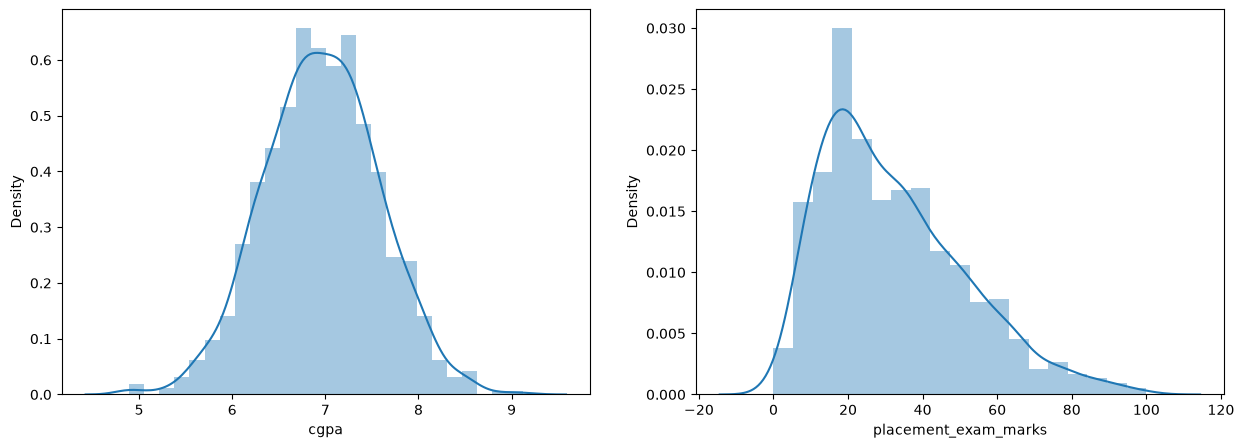

In [148]:
plt.figure(figsize= (15, 5))

plt.subplot(121)
sns.distplot(placement["cgpa"])

plt.subplot(122)
sns.distplot(placement["placement_exam_marks"])

In [149]:
cgpa_mean = placement["cgpa"].mean()
cgpa_std = placement["cgpa"].std()
cgpa_min = placement["cgpa"].min()
cgpa_max = placement["cgpa"].max()

cgpa_upper_bound = cgpa_mean + (3 * cgpa_std)
cgpa_lower_bound = cgpa_mean - (3 * cgpa_std)

print(f"mean: {cgpa_mean}\tstd: {cgpa_std}\tmin : {cgpa_min}\tmax: {cgpa_max}\tUpper Bound: {cgpa_upper_bound}\tLower Bound: {cgpa_lower_bound}")

mean: 6.96124	std: 0.6158978751323896	min : 4.89	max: 9.12	Upper Bound: 8.808933625397168	Lower Bound: 5.113546374602832


In [150]:
placement[(placement["cgpa"] < cgpa_lower_bound) | (placement["cgpa"] > cgpa_upper_bound)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# TRIMMING

In [151]:
new_placement = placement.drop(placement[(placement["cgpa"] < cgpa_lower_bound) | (placement["cgpa"] > cgpa_upper_bound)].index)

In [152]:
placement.shape, new_placement.shape

((1000, 3), (995, 3))

In [153]:
new_placement[(new_placement["cgpa"] < cgpa_lower_bound) | (new_placement["cgpa"] > cgpa_upper_bound)]

,cgpa,placement_exam_marks,placed


By Z-Score

In [154]:
z_placement = placement.copy()
z_placement["z-score"] = (z_placement["cgpa"] - z_placement["cgpa"].mean()) / z_placement["cgpa"].std()
z_placement.sample(10)

,cgpa,placement_exam_marks,placed,z-score
961,7.65,9.0,0,1.118302
726,7.93,25.0,0,1.572923
496,7.52,35.0,1,0.907228
739,6.34,39.0,0,-1.008674
914,6.97,25.0,0,0.014223
51,6.24,28.0,1,-1.171038
439,6.67,10.0,1,-0.472871
182,6.87,76.0,0,-0.148141
708,7.91,50.0,0,1.540450
994,6.48,63.0,0,-0.781363


In [155]:
z_placement[(z_placement["z-score"] < -3) | (z_placement["z-score"] > 3)]


,cgpa,placement_exam_marks,placed,z-score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [156]:
z_placement.drop(z_placement[(z_placement["z-score"] < -3) | (z_placement["z-score"] > 3)].index, inplace= True)


# CAPPING

In [157]:
c_placement = placement.copy()

c_placement["cgpa"] = np.where(
    c_placement["cgpa"] > cgpa_upper_bound, 
    cgpa_upper_bound, 
    np.where(
        c_placement["cgpa"] < cgpa_lower_bound,
        cgpa_lower_bound,
        c_placement["cgpa"]
    )
)



In [158]:
c_placement

,cgpa,placement_exam_marks,placed
0,7.190000,26.0,1
1,7.460000,38.0,1
2,7.540000,40.0,1
3,6.420000,8.0,1
4,7.230000,17.0,0
...,...,...,...
995,8.808934,44.0,1
996,8.808934,65.0,1
997,5.113546,34.0,0
998,8.620000,46.0,1


<Axes: title={'center': 'C Placement'}, ylabel='Density'>

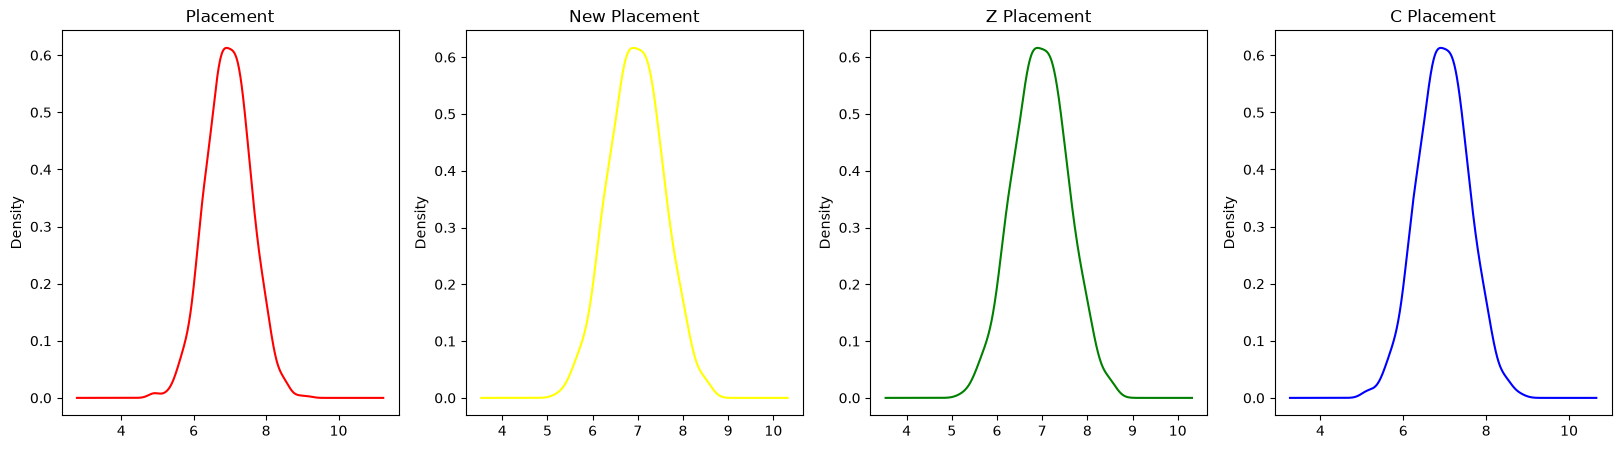

In [162]:
plt.figure(figsize= (20, 5))

plt.subplot(141)
plt.title("Placement")
placement["cgpa"].plot(kind= "kde", color= "red")

plt.subplot(142)
plt.title("New Placement")
new_placement["cgpa"].plot(kind= "kde", color= "yellow")

plt.subplot(143)
plt.title("Z Placement")
z_placement["cgpa"].plot(kind= "kde", color= "green")

plt.subplot(144)
plt.title("C Placement")
c_placement["cgpa"].plot(kind= "kde", color= "blue")